# Global IKEA Pricing & Product Value Analysis

## Project Overview

IKEA sells many of the same products across international markets, but prices,
customer ratings, and review activity can vary substantially across countries.

This project analyzes IKEA's global product catalog to investigate how prices
vary for comparable products across markets and to identify products that offer
strong customer value relative to similar products.

Rather than comparing products only on raw price or average rating, the analysis
accounts for international pricing differences, product category, customer review
volume, and the reliability of product ratings.

## Research Questions

1. How much do prices for the same IKEA products vary across countries?
2. Which countries tend to price comparable IKEA products above or below their
   international median price?
3. Is product price associated with customer rating after accounting for review
   volume and market differences?
4. Which IKEA products provide the strongest customer value relative to similar
   products in the same market and category?

## Analytical Strategy

The analysis will:

1. Audit and clean the global IKEA catalog.
2. Standardize international prices into USD.
3. Distinguish product country listings from unique products.
4. Compare identical products across international markets.
5. Adjust customer ratings for review volume.
6. Develop a category relative customer value score.
7. Use statistical modeling to evaluate the price rating relationship.
8. Test whether changing analysis choices still reach the same conclusion.
9. Export a processed dataset for an interactive Tableau dashboard.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pdfplumber

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "IKEA_product_catalog.csv"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

EXTERNAL_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "external"
)

EXCHANGE_RATE_PDF_PATH = (
    EXTERNAL_DATA_DIR
    / "Rates_of_Exchange_03312026.pdf"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
)

TABLEAU_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "tableau"
)

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLEAU_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RAW_DATA_PATH

PosixPath('/Users/andrewzhou/Desktop/ikea-global-pricing-analysis/data/raw/IKEA_product_catalog.csv')

In [3]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"IKEA dataset not found at: {RAW_DATA_PATH.resolve()}"
    )

if not EXCHANGE_RATE_PDF_PATH.exists():
    raise FileNotFoundError(
        f"Exchange-rate PDF not found at: "
        f"{EXCHANGE_RATE_PDF_PATH.resolve()}"
    )

In [4]:
ikea_raw = pd.read_csv(
    RAW_DATA_PATH,
    low_memory=False
)

ikea_raw.head()

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,none,NONE,Australia
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,none,NONE,Austria
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,none,NONE,Bahrain
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,none,NONE,Belgium
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,none,NONE,Canada


In [5]:
ikea_raw.shape

(401046, 18)

## 2. Understanding the Unit of Analysis

The dataset contains product listings from multiple IKEA markets. A single
`product_id` may therefore appear multiple times because the same product is
sold in multiple countries.

For this project:

- `unique_id` represents a product and the country that its from.
- `product_id` identifies the IKEA product.
- One product can have multiple observations because of different countries.

Each row is a combination of one product and one country. 

The distinction between these two categories is important because I will compare products with the same product ID but different unique ID's to compare prices across country. But, I'll combine country listing for the same product when ranking products globally. 

## 3. Data Audit

In [6]:
ikea_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 401046 entries, 0 to 401045
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   unique_id             401046 non-null  str    
 1   product_id            401046 non-null  int64  
 2   product_name          401046 non-null  str    
 3   product_type          401046 non-null  str    
 4   product_measurements  401046 non-null  str    
 5   product_description   401046 non-null  str    
 6   main_category         401046 non-null  str    
 7   sub_category          401046 non-null  str    
 8   product_rating        401046 non-null  str    
 9   product_rating_count  401046 non-null  str    
 10  badge                 401046 non-null  str    
 11  online_sellable       401046 non-null  bool   
 12  url                   401046 non-null  str    
 13  price                 401046 non-null  float64
 14  currency              401046 non-null  str    
 15  discount   

In [7]:
ikea_raw.head()

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,none,NONE,Australia
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,none,NONE,Austria
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,none,NONE,Bahrain
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,none,NONE,Belgium
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,none,NONE,Canada


In [8]:
ikea_raw.dtypes

unique_id                   str
product_id                int64
product_name                str
product_type                str
product_measurements        str
product_description         str
main_category               str
sub_category                str
product_rating              str
product_rating_count        str
badge                       str
online_sellable            bool
url                         str
price                   float64
currency                    str
discount                    str
sale_tag                    str
country                     str
dtype: object

In [9]:
ikea_raw.describe()

,product_id,price
count,"401,046.000","401,046.000"
mean,"49,221,846.838","14,900.415"
std,"29,819,926.476","127,424.026"
min,"28,508.000",0.100
25%,"20,582,238.000",21.990
50%,"50,404,918.000",149.000
75%,"79,281,790.000",990.000
max,"99,931,625.000","9,999,990.000"


In [10]:
ikea_raw.nlargest(10, "price")

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
303892,80245051-Colombia,80245051,STOCKHOLM,Sofá 3 puestos,none,"STOCKHOLM Sofá 3 puestos, Seglora beige",sofas-sillones,sofas,4.3,6.0,TOP_SELLER,True,https://www.ikea.com/co/es/p/stockholm-sofa-3-...,"9,999,990.000",COP,none,NONE,Colombia
210494,59477359-Colombia,59477359,VIMLE,Sofá en L 3 puestos,none,"VIMLE Sofá en L 3 puestos, Grann/Bomstad negro",camas-colchones,camas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-en-l-3...,"9,599,980.000",COP,none,TIME_RESTRICTED_OFFER,Colombia
374435,9306708-Colombia,9306708,VIMLE,Sofá 4 puestos,none,"VIMLE Sofá 4 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-4-pues...,"9,499,990.000",COP,none,NEW_LOWER_PRICE,Colombia
296977,79554276-Colombia,79554276,LANDSKRONA,Sofá de 4 puestos con chaiselongues,none,LANDSKRONA Sofá de 4 puestos con chaiselongues...,sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/landskrona-sofa-d...,"9,299,990.000",COP,none,NEW_LOWER_PRICE,Colombia
116282,39443191-Colombia,39443191,KIVIK,Sofá 4 puestos,none,"KIVIK Sofá 4 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/kivik-sofa-4-pues...,"8,499,990.000",COP,none,NONE,Colombia
335574,89443184-Colombia,89443184,KIVIK,Sofá 3 puestos,none,"KIVIK Sofá 3 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,none,True,https://www.ikea.com/co/es/p/kivik-sofa-3-pues...,"7,999,990.000",COP,none,NONE,Colombia
374395,9306261-Colombia,9306261,VIMLE,Sofá 3 puestos,none,"VIMLE Sofá 3 puestos, Con chaiselongue con apo...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-3-pues...,"7,499,990.000",COP,none,NEW_LOWER_PRICE,Colombia
332338,89306686-Colombia,89306686,VIMLE,Sofá 3 puestos,none,"VIMLE Sofá 3 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-3-pues...,"7,199,990.000",COP,none,NEW_LOWER_PRICE,Colombia
118519,39534902-Colombia,39534902,HAVSTA,Combi almacenaje puertas vidrio,243x47x212 cm,"HAVSTA Combi almacenaje puertas vidrio, blanco...",almacenamiento-organizacion,vitrinas-almacenamiento,5.0,1.0,none,True,https://www.ikea.com/co/es/p/havsta-combi-alma...,"7,199,940.000",COP,none,NEW_LOWER_PRICE,Colombia
365736,90586092-Colombia,90586092,STOCKHOLM 2025,Sofá 3 puestos,none,"STOCKHOLM 2025 Sofá 3 puestos, Sundhamn beige",sofas-sillones,sofas,5.0,2.0,none,True,https://www.ikea.com/co/es/p/stockholm-2025-so...,"6,999,990.000",COP,none,NONE,Colombia


In [11]:
ikea_raw.product_rating.unique()

<StringArray>
[ '3.3',  '1.0',  '3.7',  '4.0',  '4.8',  '4.5',  '4.2',  '1.5',  '3.8',
 'none',  '4.4',  '3.9',  '4.3',  '4.1',  '4.6',  '4.9',  '4.7',  '5.0',
  '2.5',  '3.0',  '3.1',  '3.5',  '2.0',  '3.6',  '1.3',  '3.4',  '2.7',
  '2.3',  '2.6',  '2.4',  '1.7',  '3.2',  '2.8',  '2.1',  '2.9',  '1.8',
  '1.4',  '2.2',  '1.9',  '1.6',  '1.2']
Length: 41, dtype: str

In [12]:
ikea_raw.product_rating_count.value_counts()

product_rating_count
none      131960
1.0        32080
2.0        18975
3.0        13402
4.0        10597
           ...  
705.0          1
1621.0         1
581.0          1
1092.0         1
854.0          1
Name: count, Length: 1453, dtype: int64

In [13]:
ikea_raw.currency.unique()

<StringArray>
['AUD', 'EUR', 'BHD', 'CAD', 'CLP', 'COP', 'CZK', 'DKK', 'EGP', 'HUF', 'INR',
 'JPY', 'JOD', 'KWD', 'MYR', 'MXN', 'MAD', 'NZD', 'NOK', 'OMR', 'PHP', 'PLN',
 'QAR', 'RON', 'SAR', 'RSD', 'SGD', 'KRW', 'SEK', 'CHF', 'THB', 'AED', 'GBP',
 'USD']
Length: 34, dtype: str

In [14]:
audit_summary = pd.Series({
    "Rows": len(ikea_raw),
    "Columns": ikea_raw.shape[1],
    "Unique listing IDs": ikea_raw["unique_id"].nunique(),
    "Unique products": ikea_raw["product_id"].nunique(),
    "Countries": ikea_raw["country"].nunique(),
    "Currencies": ikea_raw["currency"].nunique(),
    "Main categories": ikea_raw["main_category"].nunique(),
    "Exact duplicate rows": ikea_raw.duplicated().sum(),
    "Duplicate unique IDs": ikea_raw["unique_id"].duplicated().sum()
})

audit_summary

Rows                    401046
Columns                     18
Unique listing IDs      401046
Unique products          34932
Countries                   46
Currencies                  34
Main categories            314
Exact duplicate rows         0
Duplicate unique IDs         0
dtype: int64

In [15]:
ikea_raw.isna().sum().sort_values(ascending=False)

unique_id               0
product_id              0
sale_tag                0
discount                0
currency                0
price                   0
url                     0
online_sellable         0
badge                   0
product_rating_count    0
product_rating          0
sub_category            0
main_category           0
product_description     0
product_measurements    0
product_type            0
product_name            0
country                 0
dtype: int64

In [16]:
ikea_raw.country.unique()

<StringArray>
[     'Australia',        'Austria',        'Bahrain',        'Belgium',
         'Canada',          'Chile',       'Colombia',        'Croatia',
 'Czech_Republic',        'Denmark',          'Egypt',        'Finland',
         'France',        'Germany',        'Hungary',          'India',
        'Ireland',          'Italy',          'Japan',         'Jordan',
         'Kuwait',       'Malaysia',         'Mexico',        'Morocco',
    'Netherlands',    'New_Zealand',         'Norway',           'Oman',
    'Philippines',         'Poland',       'Portugal',          'Qatar',
        'Romania',   'Saudi_Arabia',         'Serbia',      'Singapore',
       'Slovakia',       'Slovenia',    'South_Korea',          'Spain',
         'Sweden',    'Switzerland',       'Thailand',            'UAE',
             'UK',            'USA']
Length: 46, dtype: str

In [17]:
product_country_counts = (
    ikea_raw
    .groupby("product_id")["country"]
    .nunique()
)

product_country_counts.describe()

count   34,932.000
mean        11.481
std         13.842
min          1.000
25%          1.000
50%          5.000
75%         17.000
max         46.000
Name: country, dtype: float64

In [18]:
product_country_counts.sort_values(
    ascending=False
).head(20)

product_id
28508       46
30366917    46
30468119    46
30455089    46
30454004    46
30444468    46
30443930    46
30432502    46
30424385    46
30408979    46
30404028    46
30373588    46
30333583    46
30485350    46
30333125    46
30328534    46
30326177    46
30298396    46
30258913    46
30213552    46
Name: country, dtype: int64

### Data Audit Findings

- The dataset contains approximately 401,046 product country listings representing
  34,932 unique IKEA products across 46 countries.
- Individual products often appear in multiple countries, confirming that
  `unique_id` and `product_id` represent different units.
- Several columns use textual missing value indicators such as `"none"` rather
  than true null values. Need to convert.
- International prices are stored in local currencies and cannot be compared
  directly.
- The number of countries in which a product appears varies substantially, so
  international price comparisons should require a minimum amount of countries where the product is sold.

## 4. Data Cleaning

In [19]:
ikea = ikea_raw.copy()

In [20]:
text_cols = ikea.select_dtypes(
    include=["object", "string"]
).columns

for col in text_cols:
    ikea[col] = (
        ikea[col]
        .astype("string")
        .str.strip()
    )

In [21]:
missing_tokens = ["none","NONE","None","", " "]
ikea[text_cols] = (ikea[text_cols].replace(missing_tokens, np.nan))

In [22]:
ikea["product_rating"] = pd.to_numeric(ikea["product_rating"],errors="coerce")
ikea["product_rating_count"] = pd.to_numeric(ikea["product_rating_count"], errors="coerce")
ikea["price"] = pd.to_numeric(ikea["price"],errors="coerce")

In [23]:
ikea[["product_rating","product_rating_count","price"]].dtypes

product_rating          Float64
product_rating_count    Float64
price                   float64
dtype: object

In [24]:
ikea["product_rating"].describe()

count   269,086.000
mean          4.455
std           0.618
min           1.000
25%           4.300
50%           4.600
75%           4.800
max           5.000
Name: product_rating, dtype: Float64

In [25]:
ikea[ikea["product_rating"].notna() & ~ikea["product_rating"].between(1, 5)]

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country


In [26]:
ikea["price"].describe()

count     401,046.000
mean       14,900.415
std       127,424.026
min             0.100
25%            21.990
50%           149.000
75%           990.000
max     9,999,990.000
Name: price, dtype: float64

In [27]:
ikea[ikea["price"].notna() & (ikea["price"] <= 0)]

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country


In [28]:
ikea["product_rating_count"].describe()

count   269,086.000
mean        181.287
std         592.599
min           1.000
25%           4.000
50%          18.000
75%          98.000
max      10,058.000
Name: product_rating_count, dtype: Float64

In [29]:
ikea[ikea["product_rating_count"].notna() & (ikea["product_rating_count"] < 0)]

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country


In [30]:
ikea["currency"].dropna().sort_values().unique()

<StringArray>
['AED', 'AUD', 'BHD', 'CAD', 'CHF', 'CLP', 'COP', 'CZK', 'DKK', 'EGP', 'EUR',
 'GBP', 'HUF', 'INR', 'JOD', 'JPY', 'KRW', 'KWD', 'MAD', 'MXN', 'MYR', 'NOK',
 'NZD', 'OMR', 'PHP', 'PLN', 'QAR', 'RON', 'RSD', 'SAR', 'SEK', 'SGD', 'THB',
 'USD']
Length: 34, dtype: string

In [31]:
rows = []

with pdfplumber.open(
    EXCHANGE_RATE_PDF_PATH
) as pdf:

    # Skip the cover page
    for page in pdf.pages[1:]:

        table = page.extract_table()

        for row in table:

            if (
                len(row) == 3
                and row[2] == "3/31/2026"
            ):
                rows.append(row)

In [32]:
exchange_rates = pd.DataFrame(
    rows,
    columns=[
        "country_currency",
        "foreign_currency_per_usd",
        "rate_date"
    ]
)

exchange_rates.head()

,country_currency,foreign_currency_per_usd,rate_date
0,Afghanistan-Afghani,64.7700,3/31/2026
1,Albania-Lek,83.3000,3/31/2026
2,Algeria-Dinar,132.5960,3/31/2026
3,Angola-Kwanza,912.1300,3/31/2026
4,Antigua & Barbuda-E. Caribbean Dollar,2.7000,3/31/2026


In [33]:
exchange_rates["foreign_currency_per_usd"] = pd.to_numeric(
    exchange_rates["foreign_currency_per_usd"].str.replace(",", "", regex=False)
)

exchange_rates["rate_date"] = pd.to_datetime(
    exchange_rates["rate_date"]
)

In [34]:
exchange_rates["usd_per_currency"] = (
    1 / exchange_rates["foreign_currency_per_usd"]
)

In [35]:
exchange_rates

,country_currency,foreign_currency_per_usd,rate_date,usd_per_currency
0,Afghanistan-Afghani,64.770,2026-03-31,0.015
1,Albania-Lek,83.300,2026-03-31,0.012
2,Algeria-Dinar,132.596,2026-03-31,0.008
3,Angola-Kwanza,912.130,2026-03-31,0.001
4,Antigua & Barbuda-E. Caribbean Dollar,2.700,2026-03-31,0.370
...,...,...,...,...
160,Vietnam-Dong,"26,323.000",2026-03-31,0.000
161,Western Samoa-Tala,2.667,2026-03-31,0.375
162,Yemen-Rial,528.000,2026-03-31,0.002
163,Zambia-New Kwacha,19.135,2026-03-31,0.052


In [36]:
currency_map = {
    "Australia-Dollar": "AUD",
    "Euro Zone-Euro": "EUR",
    "Bahrain-Dinar": "BHD",
    "Canada-Dollar": "CAD",
    "Chile-Peso": "CLP",
    "Colombia-Peso": "COP",
    "Czech Republic-Koruna": "CZK",
    "Denmark-Krone": "DKK",
    "Egypt-Pound": "EGP",
    "Hungary-Forint": "HUF",
    "India-Rupee": "INR",
    "Japan-Yen": "JPY",
    "Jordan-Dinar": "JOD",
    "Kuwait-Dinar": "KWD",
    "Malaysia-Ringgit": "MYR",
    "Mexico-Peso": "MXN",
    "Morocco-Dirham": "MAD",
    "New Zealand-Dollar": "NZD",
    "Norway-Krone": "NOK",
    "Oman-Rial": "OMR",
    "Philippines-Peso": "PHP",
    "Poland-Zloty": "PLN",
    "Qatar-Riyal": "QAR",
    "Romania-New Leu": "RON",
    "Saudi Arabia-Riyal": "SAR",
    "Serbia-Dinar": "RSD",
    "Singapore-Dollar": "SGD",
    "Korea-Won": "KRW",
    "Sweden-Krona": "SEK",
    "Switzerland-Franc": "CHF",
    "Thailand-Baht": "THB",
    "United Arab Emirates-Dirham": "AED",
    "United Kingdom-Pound": "GBP"
}

In [37]:
ikea_exchange_rates = exchange_rates[
    exchange_rates["country_currency"].isin(currency_map)
].copy()

ikea_exchange_rates["currency"] = (
    ikea_exchange_rates["country_currency"].map(currency_map)
)

In [38]:
ikea_exchange_rates = ikea_exchange_rates[
    ["currency", "usd_per_currency", "rate_date"]
]

ikea_exchange_rates

,currency,usd_per_currency,rate_date
7,AUD,0.688,2026-03-31
10,BHD,2.653,2026-03-31
26,CAD,0.718,2026-03-31
31,CLP,0.001,2026-03-31
33,COP,0.000,2026-03-31
41,CZK,0.048,2026-03-31
43,DKK,0.154,2026-03-31
47,EGP,0.018,2026-03-31
53,EUR,1.149,2026-03-31
67,HUF,0.003,2026-03-31


In [39]:
usd_row = pd.DataFrame({
    "currency": ["USD"],
    "usd_per_currency": [1.0],
    "rate_date": [pd.Timestamp("2026-03-31")]
})

ikea_exchange_rates = pd.concat(
    [ikea_exchange_rates, usd_row],
    ignore_index=True
)

In [40]:
ikea_currencies = set(
    ikea["currency"]
    .dropna()
    .unique()
)

fx_currencies = set(
    ikea_exchange_rates["currency"]
)

missing_fx = (
    ikea_currencies
    - fx_currencies
)

if missing_fx:
    raise ValueError(
        f"Missing exchange rates for: "
        f"{sorted(missing_fx)}"
    )

if (
    ikea_exchange_rates["currency"]
    .duplicated()
    .any()
):
    raise ValueError(
        "Duplicate exchange rates found."
    )

print(
    "All IKEA currencies have "
    "exactly one exchange rate."
)

All IKEA currencies have exactly one exchange rate.


## Merge Exchange Rates and Convert Prices to USD

In [41]:
ikea["price"].dtype

dtype('float64')

In [42]:
ikea = ikea.merge(
    ikea_exchange_rates[
        ["currency", "usd_per_currency", "rate_date"]
    ],
    on="currency",
    how="left",
    validate="many_to_one"
)

In [43]:
ikea["usd_per_currency"].isna().sum()

np.int64(0)

In [44]:
ikea.loc[
    ikea["usd_per_currency"].isna(),
    "currency"
].value_counts()

Series([], Name: count, dtype: int64)

In [45]:
ikea["price_usd"] = (
    ikea["price"] *
    ikea["usd_per_currency"]
)

In [46]:
ikea[
    [
        "country",
        "currency",
        "price",
        "usd_per_currency",
        "price_usd"
    ]
].head(20)

,country,currency,price,usd_per_currency,price_usd
0,Australia,AUD,30.000,0.688,20.647
1,Austria,EUR,27.990,1.149,32.172
2,Bahrain,BHD,9.500,2.653,25.199
3,Belgium,EUR,29.990,1.149,34.471
4,Canada,CAD,34.990,0.718,25.118
5,Chile,CLP,"26,990.000",0.001,29.123
6,Colombia,COP,"139,990.000",0.000,38.184
7,Croatia,EUR,19.990,1.149,22.977
8,Czech_Republic,CZK,699.000,0.048,33.565
9,Denmark,DKK,199.000,0.154,30.611


In [47]:
ikea.loc[
    ikea["currency"] == "USD",
    ["price", "usd_per_currency", "price_usd"]
].head()

,price,usd_per_currency,price_usd
45,34.990,1.000,34.990
115,4.990,1.000,4.990
128,12.990,1.000,12.990
170,65.000,1.000,65.000
216,59.000,1.000,59.000


In [48]:
ikea["price_usd"].describe()

count   401,046.000
mean        177.979
std         324.251
min           0.179
25%          10.614
50%          41.253
75%         195.402
max       7,482.749
Name: price_usd, dtype: float64

In [49]:
ikea["price_usd"].isna().sum()

np.int64(0)

In [50]:
ikea.loc[
    ikea["price_usd"] <= 0,
    ["product_name", "country", "currency", "price", "price_usd"]
]

,product_name,country,currency,price,price_usd


In [51]:
ikea.to_csv(
    PROCESSED_DATA_DIR / "ikea_cleaned.csv",
    index=False
)

In [52]:
price_df = ikea.dropna(
    subset=[
        "unique_id",
        "product_id",
        "country",
        "price_usd"
    ]
).copy()

In [53]:
price_df

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country,usd_per_currency,rate_date,price_usd
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.300,140.000,<NA>,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,<NA>,<NA>,Australia,0.688,2026-03-31,20.647
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.300,6.000,<NA>,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,<NA>,<NA>,Austria,1.149,2026-03-31,32.172
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.000,1.000,<NA>,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,<NA>,<NA>,Bahrain,2.653,2026-03-31,25.199
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,<NA>,<NA>,Belgium,1.149,2026-03-31,34.471
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,<NA>,<NA>,Canada,0.718,2026-03-31,25.118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401041,99931611-Serbia,99931611,MALM,"Okvir kreveta,vis. s 4 kut.odlag.",160x200 cm,"MALM Okvir kreveta,vis. s 4 kut.odlag., bela, ...",kreveti-i-duseci,kreveti,4.300,798.000,<NA>,True,https://www.ikea.com/rs/sr/p/malm-okvir-krevet...,"37,999.000",RSD,<NA>,NEW_LOWER_PRICE,Serbia,0.010,2026-03-31,372.211
401042,99931611-Slovenia,99931611,MALM,"Post okvir, visok, s 4 predali",160x200 cm,"Bel okvir postelje MALM s preprostim, sodobnim...",postelje-in-posteljni-vlozki,cenovno-ugodne-postelje,4.300,798.000,<NA>,True,https://www.ikea.com/si/sl/p/malm-post-okvir-v...,339.000,EUR,<NA>,NEW_LOWER_PRICE,Slovenia,1.149,2026-03-31,389.655
401043,99931625-Egypt,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,4.300,3.000,<NA>,True,https://www.ikea.com/eg/en/p/malm-bed-frame-hi...,"26,295.000",EGP,<NA>,<NA>,Egypt,0.018,2026-03-31,481.770
401044,99931625-Jordan,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,<NA>,<NA>,<NA>,True,https://www.ikea.com/jo/en/p/malm-bed-frame-hi...,345.000,JOD,<NA>,<NA>,Jordan,1.412,2026-03-31,487.288


In [54]:
price_df = price_df[
    price_df["price_usd"] > 0
].copy()

In [55]:
rating_df = ikea.dropna(
    subset=[
        "product_id",
        "country",
        "product_rating",
        "product_rating_count",
        "price_usd"
    ]
).copy()

In [56]:
rating_df["product_rating"].between(
    1, 5
).all()

np.True_

## 5. International Pricing Analysis

In [57]:
market_counts = (price_df.groupby("product_id")["country"].nunique().rename("n_markets"))

In [58]:
price_df = price_df.merge(market_counts,on="product_id",how="left")

In [59]:
MIN_MARKETS = 5
price_analysis = price_df[price_df["n_markets"] >= MIN_MARKETS].copy()

In [60]:
price_analysis["global_median_price_usd"] = (price_analysis.groupby("product_id")["price_usd"].transform("median"))

In [61]:
price_analysis[["product_name","country","price_usd","global_median_price_usd"]].head()

,product_name,country,price_usd,global_median_price_usd
0,ORDNING,Australia,20.647,31.006
1,ORDNING,Austria,32.172,31.006
2,ORDNING,Bahrain,25.199,31.006
3,ORDNING,Belgium,34.471,31.006
4,ORDNING,Canada,25.118,31.006


In [62]:
price_analysis["price_index"] = (price_analysis["price_usd"] / price_analysis["global_median_price_usd"])

In [63]:
price_analysis["price_premium_pct"] = (price_analysis["price_index"] - 1) * 100

In [64]:
price_analysis

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country,usd_per_currency,rate_date,price_usd,n_markets,global_median_price_usd,price_index,price_premium_pct
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.300,140.000,<NA>,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,<NA>,<NA>,Australia,0.688,2026-03-31,20.647,46,31.006,0.666,-33.409
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.300,6.000,<NA>,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,<NA>,<NA>,Austria,1.149,2026-03-31,32.172,46,31.006,1.038,3.762
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.000,1.000,<NA>,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,<NA>,<NA>,Bahrain,2.653,2026-03-31,25.199,46,31.006,0.813,-18.728
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,<NA>,<NA>,Belgium,1.149,2026-03-31,34.471,46,31.006,1.112,11.177
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,<NA>,<NA>,Canada,0.718,2026-03-31,25.118,46,31.006,0.810,-18.988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401038,99931611-Finland,99931611,MALM,"Bed frame, high, w 4 storage boxes",160x200 cm,"A white MALM bed frame with a simple, modern d...",beds-mattresses,beds,4.300,798.000,<NA>,True,https://www.ikea.com/fi/en/p/malm-bed-frame-hi...,359.000,EUR,<NA>,<NA>,Finland,1.149,2026-03-31,412.644,6,380.933,1.083,8.324
401039,99931611-India,99931611,MALM,"Bed frame, high, w 4 storage boxes","160x200 cm (63x78 3/4 "")","MALM Bed frame, high, w 4 storage boxes, white...",beds-mattresses,beds,4.300,798.000,<NA>,True,https://www.ikea.com/in/en/p/malm-bed-frame-hi...,"28,990.000",INR,<NA>,<NA>,India,0.011,2026-03-31,308.654,6,380.933,0.810,-18.974
401040,99931611-Netherlands,99931611,MALM,"Bed frame, high, w 4 storage boxes",160x200 cm,"A white MALM bed frame with a simple, modern d...",beds-mattresses,beds,4.500,49.000,<NA>,True,https://www.ikea.com/nl/en/p/malm-bed-frame-hi...,279.000,EUR,<NA>,<NA>,Netherlands,1.149,2026-03-31,320.690,6,380.933,0.842,-15.815
401041,99931611-Serbia,99931611,MALM,"Okvir kreveta,vis. s 4 kut.odlag.",160x200 cm,"MALM Okvir kreveta,vis. s 4 kut.odlag., bela, ...",kreveti-i-duseci,kreveti,4.300,798.000,<NA>,True,https://www.ikea.com/rs/sr/p/malm-okvir-krevet...,"37,999.000",RSD,<NA>,NEW_LOWER_PRICE,Serbia,0.010,2026-03-31,372.211,6,380.933,0.977,-2.290


In [65]:
country_price_summary = (price_analysis.groupby("country").agg(median_price_premium_pct=("price_premium_pct","median"),
        comparable_products=(
            "product_id",
            "nunique"
        )
    )
    .reset_index()
)

In [66]:
country_price_summary = (
    country_price_summary[
        country_price_summary[
            "comparable_products"
        ] >= 100
    ]
)

In [67]:
country_price_summary.sort_values(
    "median_price_premium_pct",
    ascending=False
).head(15)

,country,median_price_premium_pct,comparable_products
23,Morocco,44.738,7824
10,Egypt,42.174,7972
22,Mexico,35.780,6222
19,Jordan,27.139,8059
41,Switzerland,26.526,8840
45,USA,22.046,7639
26,Norway,16.079,9146
6,Colombia,15.443,4792
33,Saudi_Arabia,7.458,7079
1,Austria,4.276,9192


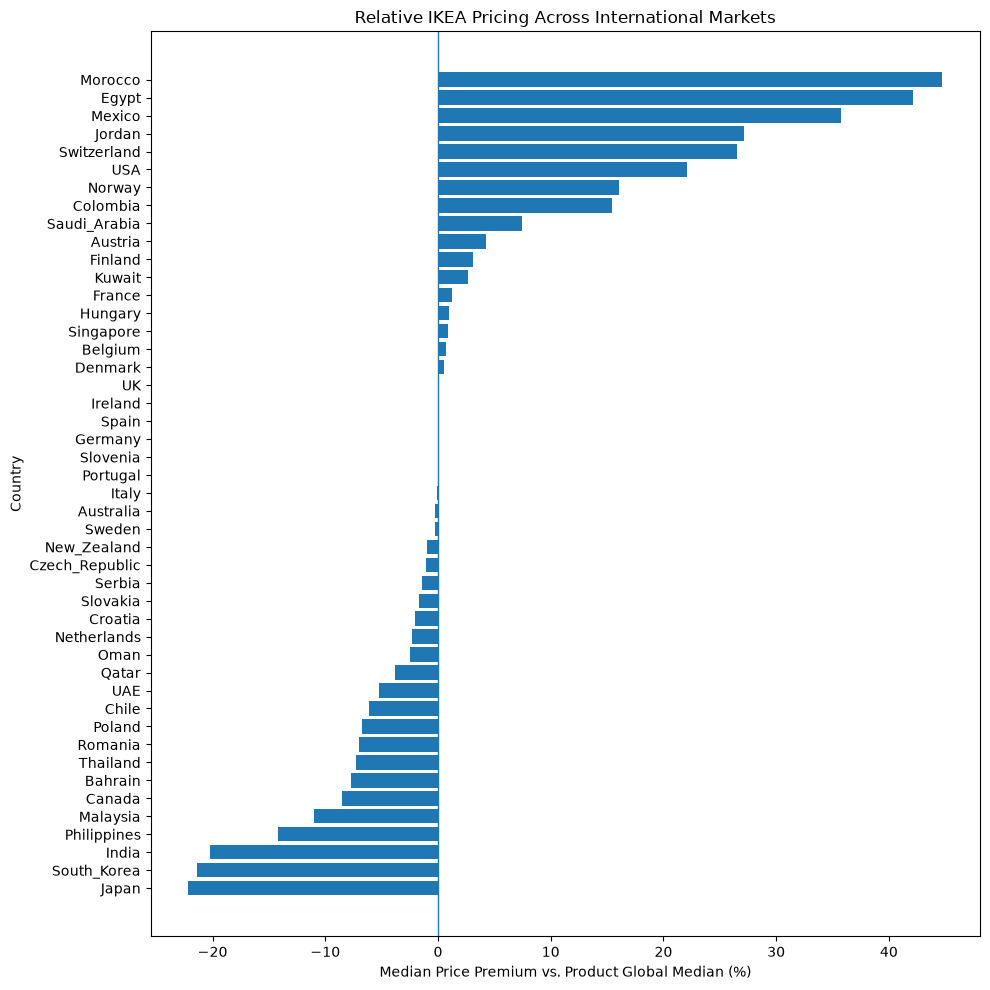

In [68]:
plot_df = (
    country_price_summary
    .sort_values(
        "median_price_premium_pct"
    )
)

plt.figure(
    figsize=(10, 10)
)

plt.barh(
    plot_df["country"],
    plot_df[
        "median_price_premium_pct"
    ]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Median Price Premium vs. "
    "Product Global Median (%)"
)

plt.ylabel(
    "Country"
)

plt.title(
    "Relative IKEA Pricing "
    "Across International Markets"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "country_price_premiums.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
product_price_dispersion = (
    price_analysis
    .groupby("product_id")
    .agg(
        product_name=("product_name", "first"),
        markets=("country", "nunique"),
        min_price_usd=("price_usd", "min"),
        median_price_usd=("price_usd", "median"),
        max_price_usd=("price_usd", "max")
    )
    .reset_index()
)

In [70]:
product_price_dispersion[
    "relative_price_range_pct"
] = (
    (
        product_price_dispersion["max_price_usd"]
        - product_price_dispersion["min_price_usd"]
    )
    / product_price_dispersion["median_price_usd"]
) * 100

In [71]:
product_price_dispersion

,product_id,product_name,markets,min_price_usd,median_price_usd,max_price_usd,relative_price_range_pct
0,28508,LEN,46,2.651,5.172,11.483,170.746
1,31841,EDSVIK,34,43.150,65.517,155.643,171.699
2,58487,FLYTTA,16,162.037,201.535,246.116,41.719
3,69768,OMAR,37,17.993,34.425,57.460,114.644
4,81534,KONCIS,46,2.753,5.743,9.950,125.323
...,...,...,...,...,...,...,...
17524,99924781,METOD,15,241.954,290.805,437.147,67.122
17525,99925653,METOD,7,260.920,317.643,557.096,93.242
17526,99929241,RÄCKA,24,5.856,11.903,26.391,172.517
17527,99929585,RÄCKA / HUGAD,37,22.891,47.784,71.218,101.137


In [72]:
product_price_dispersion[
    "relative_price_range_pct"
].describe()

count   17,529.000
mean        88.063
std         44.004
min          0.000
25%         57.201
50%         82.594
75%        111.617
max        869.868
Name: relative_price_range_pct, dtype: float64

In [73]:
top_price_dispersion = (
    product_price_dispersion
    .sort_values(
        "relative_price_range_pct",
        ascending=False
    )
    .head(10)
)

top_price_dispersion

,product_id,product_name,markets,min_price_usd,median_price_usd,max_price_usd,relative_price_range_pct
8908,50549836,UPPDATERA,43,2.874,5.747,52.866,869.868
352,465754,ENHET,13,0.531,1.246,9.184,694.256
15731,90474532,FÖRUT,17,0.522,0.862,6.195,658.131
12399,70578861,SILÄNG,30,1.248,2.441,16.585,628.332
16346,90603869,GULLSUDARE,45,2.224,4.011,26.173,596.987
5696,30558997,RELATERA,45,14.358,22.989,148.737,584.549
10329,60465751,ENHET,36,0.663,1.467,9.184,580.928
326,455547,MÅLA,45,1.631,2.299,13.754,527.356
4028,20550204,STOPP FILT,7,2.504,3.751,19.990,466.186
14341,80595332,NATTHÄGER,45,2.455,4.888,23.800,436.700


## 6. Customer Rating Reliability

In [74]:
global_mean_rating = rating_df["product_rating"].mean()

In [75]:
m = rating_df[
    "product_rating_count"
].median()

global_mean_rating, m

(np.float64(4.455271177244449), np.float64(18.0))

In [76]:
R = rating_df["product_rating"]
v = rating_df["product_rating_count"]

rating_df["weighted_rating"] = (
    (v / (v + m)) * R
    + (m / (v + m)) * global_mean_rating
)

In [77]:
def create_value_scores(
    df,
    min_reviews=50,
    min_category_size=20
):

    temp = df[
        df["product_rating_count"] >= min_reviews
    ].copy()

    temp = temp.dropna(
        subset=[
            "country",
            "main_category",
            "weighted_rating",
            "price_usd"
        ]
    )

    temp["category_market_size"] = (
        temp
        .groupby(
            ["country", "main_category"]
        )["product_id"]
        .transform("nunique")
    )

    temp = temp[
        temp["category_market_size"] >= min_category_size
    ].copy()

    temp["rating_percentile"] = (
        temp
        .groupby(
            ["country", "main_category"]
        )["weighted_rating"]
        .rank(
            pct=True,
            method="average"
        )
    )

    temp["price_percentile"] = (
        temp
        .groupby(
            ["country", "main_category"]
        )["price_usd"]
        .rank(
            pct=True,
            method="average"
        )
    )

    temp["value_score"] = (
        temp["rating_percentile"]
        - temp["price_percentile"]
    )

    return temp

In [78]:
MIN_REVIEWS = 50
MIN_CATEGORY_SIZE = 20

value_df = create_value_scores(
    rating_df,
    min_reviews=MIN_REVIEWS,
    min_category_size=MIN_CATEGORY_SIZE
)

value_df.shape

(91206, 26)

In [79]:
def summarize_product_value(
    value_data,
    min_markets=3
):

    summary = (
        value_data
        .groupby("product_id")
        .agg(
            product_name=(
                "product_name",
                "first"
            ),
            median_value_score=(
                "value_score",
                "median"
            ),
            mean_value_score=(
                "value_score",
                "mean"
            ),
            markets_evaluated=(
                "country",
                "nunique"
            ),
            median_weighted_rating=(
                "weighted_rating",
                "median"
            ),
            median_price_usd=(
                "price_usd",
                "median"
            ),
            max_review_count=(
                "product_rating_count",
                "max"
            )
        )
        .reset_index()
    )

    summary = summary[
        summary["markets_evaluated"]
        >= min_markets
    ].copy()

    return summary

In [80]:
product_value = summarize_product_value(
    value_df,
    min_markets=3
)

In [81]:
top_value_products = (
    product_value
    .sort_values(
        "median_value_score",
        ascending=False
    )
    .head(10)
)

top_value_products

,product_id,product_name,median_value_score,mean_value_score,markets_evaluated,median_weighted_rating,median_price_usd,max_review_count
3842,30530951,SNÖSKYFFEL,0.987,0.961,25,4.793,0.656,936.000
1882,10591318,FÖRSIKTIG,0.980,0.859,23,4.846,4.586,131.000
421,470982,FINSMAK,0.973,0.889,28,4.874,0.460,612.000
9255,80621816,POKAL,0.964,0.961,14,4.819,0.793,81.000
7003,60568546,KUGGIS,0.963,0.853,24,4.790,1.713,610.000
8498,80258915,OFTAST,0.952,0.904,35,4.798,0.720,"3,927.000"
7089,60591014,BAGIS,0.949,0.828,23,4.772,2.287,206.000
3085,20611108,FRAKTA,0.939,0.910,5,4.799,0.862,"8,915.000"
6101,50590760,FODERTRÅG,0.939,0.938,4,4.822,3.673,85.000
8007,70568560,KUGGIS,0.938,0.867,18,4.790,3.310,610.000


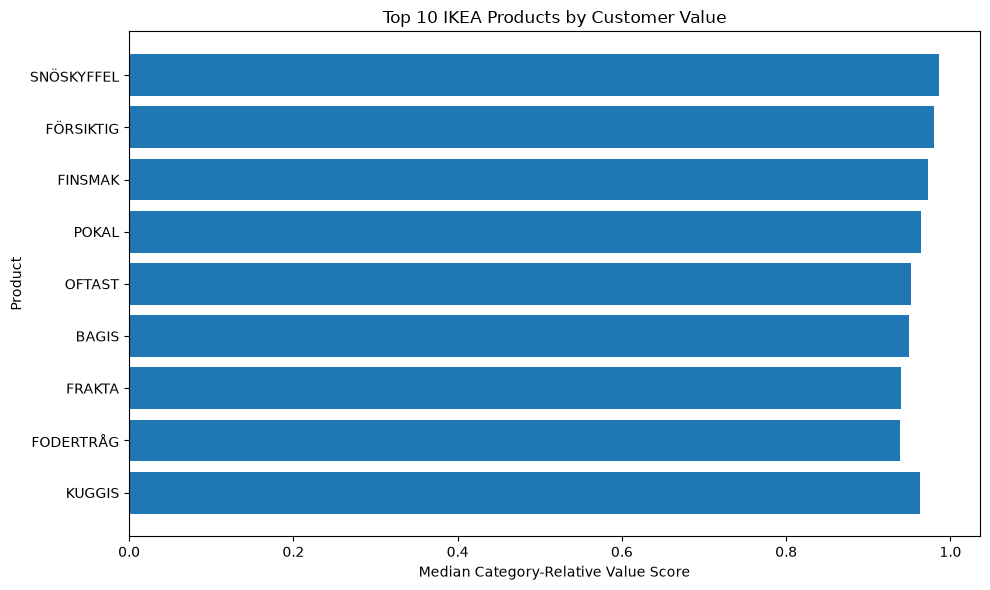

In [82]:
plot_df = (
    top_value_products
    .sort_values("median_value_score")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["product_name"],
    plot_df["median_value_score"]
)

plt.xlabel("Median Category-Relative Value Score")
plt.ylabel("Product")

plt.title(
    "Top 10 IKEA Products by Customer Value"
)

plt.tight_layout()
plt.show()

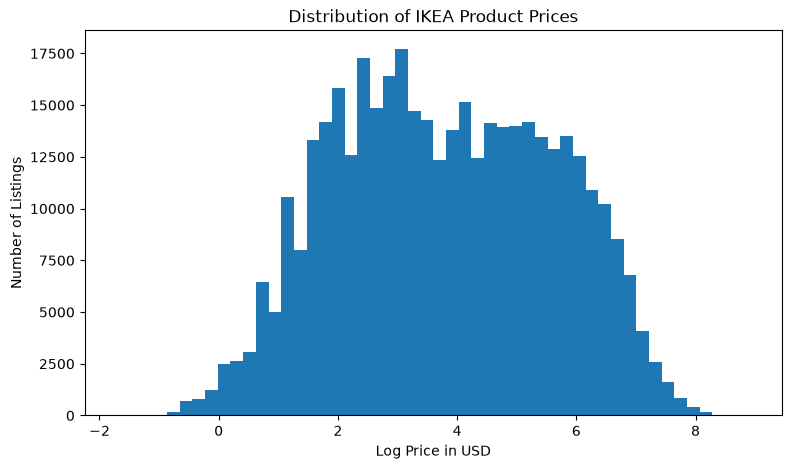

In [83]:
plt.figure(figsize=(9, 5))

plt.hist(
    np.log(price_df["price_usd"]),
    bins=50
)

plt.xlabel("Log Price in USD")
plt.ylabel("Number of Listings")

plt.title(
    "Distribution of IKEA Product Prices"
)

plt.show()

In [84]:
rating_df["log_price_usd"] = np.log(
    rating_df["price_usd"]
)

In [85]:
plot_sample = rating_df.sample(
    min(20000, len(rating_df)),
    random_state=42
)

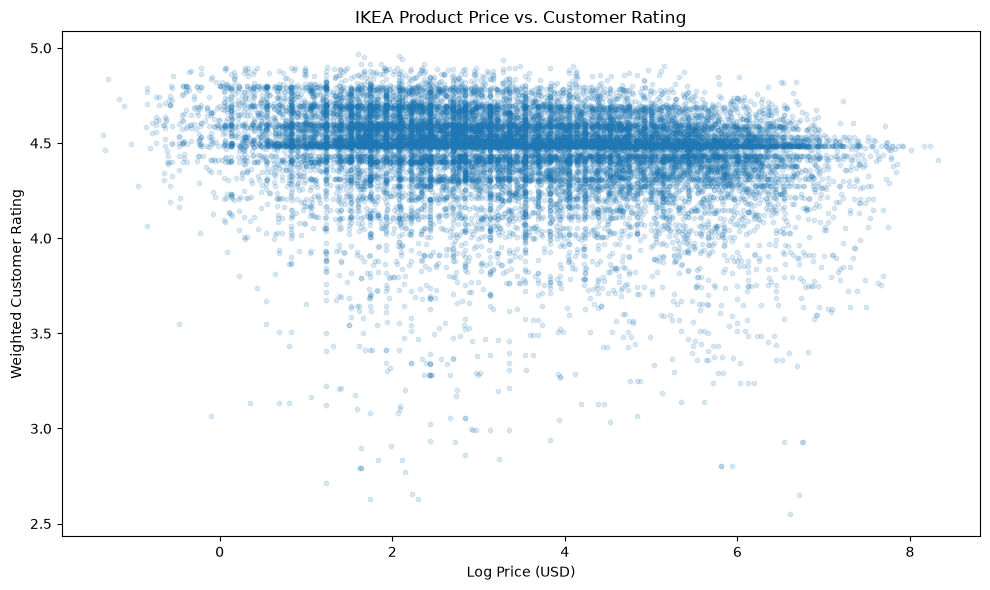

In [86]:
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_sample["log_price_usd"],
    plot_sample["weighted_rating"],
    alpha=0.15,
    s=10
)

plt.xlabel("Log Price (USD)")
plt.ylabel("Weighted Customer Rating")
plt.title("IKEA Product Price vs. Customer Rating")

plt.tight_layout()
plt.show()

In [87]:
rating_df["log_review_count"] = np.log1p(
    rating_df["product_rating_count"]
)

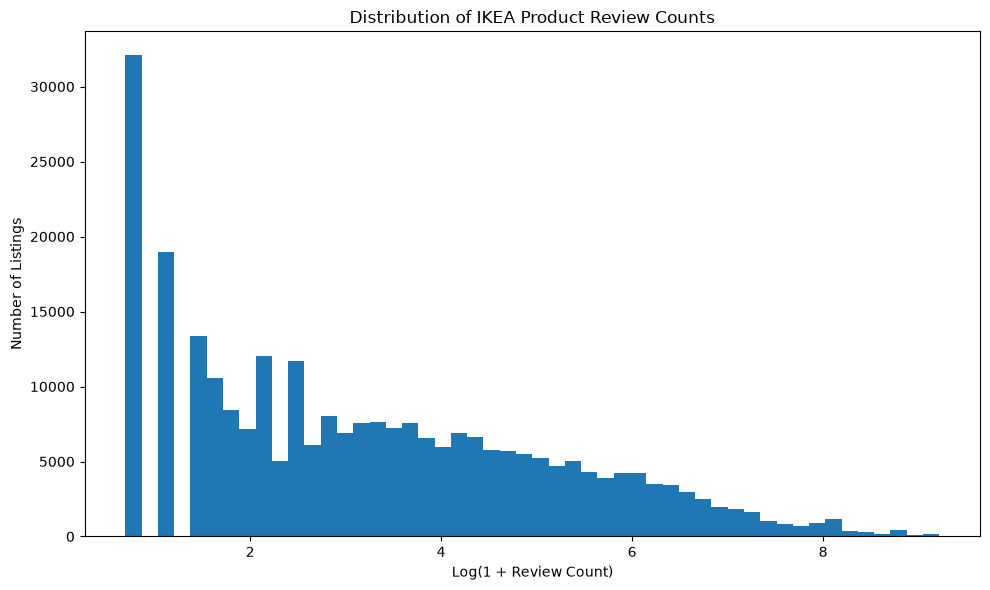

In [88]:
plt.figure(figsize=(10, 6))

plt.hist(
    rating_df["log_review_count"].dropna(),
    bins=50
)

plt.xlabel("Log(1 + Review Count)")
plt.ylabel("Number of Listings")
plt.title("Distribution of IKEA Product Review Counts")

plt.tight_layout()
plt.show()

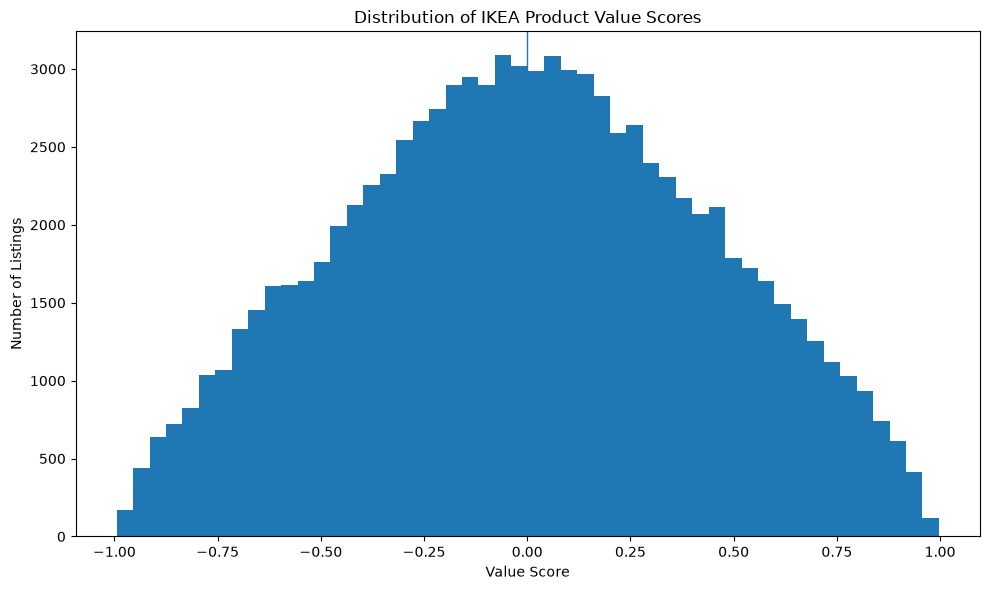

In [89]:
plt.figure(figsize=(10, 6))

plt.hist(
    value_df["value_score"].dropna(),
    bins=50
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Value Score")
plt.ylabel("Number of Listings")
plt.title("Distribution of IKEA Product Value Scores")

plt.tight_layout()
plt.show()

In [90]:
model_df = rating_df.dropna(
    subset=[
        "product_rating",
        "price_usd",
        "product_rating_count",
        "country",
        "main_category",
        "product_id"
    ]
).copy()

model_df["log_price_usd"] = np.log(
    model_df["price_usd"]
)

model_df["log_review_count"] = np.log1p(
    model_df["product_rating_count"]
)

In [91]:
MODEL_MIN_CATEGORY_SIZE = 20

model_df["category_market_size"] = (
    model_df
    .groupby(
        [
            "country",
            "main_category"
        ]
    )["product_id"]
    .transform("nunique")
)

model_df = model_df[
    model_df["category_market_size"]
    >= MODEL_MIN_CATEGORY_SIZE
].copy()

In [92]:
model_groups = [
    "country",
    "main_category"
]

model_df["rating_within_group"] = (
    model_df["product_rating"]
    - model_df
      .groupby(model_groups)[
          "product_rating"
      ]
      .transform("mean")
)

model_df["log_price_within_group"] = (
    model_df["log_price_usd"]
    - model_df
      .groupby(model_groups)[
          "log_price_usd"
      ]
      .transform("mean")
)

model_df["log_reviews_within_group"] = (
    model_df["log_review_count"]
    - model_df
      .groupby(model_groups)[
          "log_review_count"
      ]
      .transform("mean")
)

In [93]:
rating_model = smf.ols(
    formula="""
        rating_within_group
        ~ log_price_within_group
        + log_reviews_within_group
        - 1
    """,
    data=model_df
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups":
        model_df["product_id"]
    }
)

In [94]:
print(
    rating_model.summary()
)

                                 OLS Regression Results                                 
Dep. Variable:     rating_within_group   R-squared (uncentered):                   0.011
Model:                             OLS   Adj. R-squared (uncentered):              0.011
Method:                  Least Squares   F-statistic:                              150.4
Date:                 Wed, 19 Aug 2026   Prob (F-statistic):                    1.13e-65
Time:                         23:49:23   Log-Likelihood:                     -2.3737e+05
No. Observations:               267794   AIC:                                  4.747e+05
Df Residuals:                   267792   BIC:                                  4.748e+05
Df Model:                            2                                                  
Covariance Type:               cluster                                                  
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------

In [95]:
coef = rating_model.params[
    "log_price_within_group"
]

p_value = rating_model.pvalues[
    "log_price_within_group"
]

ci = (
    rating_model
    .conf_int()
    .loc[
        "log_price_within_group"
    ]
)

print(
    "Price coefficient:",
    coef
)

print(
    "P-value:",
    p_value
)

print(
    "95% confidence interval:"
)

print(ci)

Price coefficient: -0.03106492314561538
P-value: 2.4935786308102726e-31
95% confidence interval:
0   -0.036
1   -0.026
Name: log_price_within_group, dtype: float64


In [96]:
ten_percent_effect = (
    coef
    * np.log(1.10)
)

print(
    "Estimated rating change "
    "for a 10% higher price:",
    ten_percent_effect
)

Estimated rating change for a 10% higher price: -0.002960803410616137


In [97]:
value_25 = create_value_scores(
    rating_df,
    min_reviews=25
)

value_50 = create_value_scores(
    rating_df,
    min_reviews=50
)

value_100 = create_value_scores(
    rating_df,
    min_reviews=100
)

In [98]:
product_value_25 = (
    summarize_product_value(
        value_25,
        min_markets=3
    )
)

product_value_50 = (
    summarize_product_value(
        value_50,
        min_markets=3
    )
)

product_value_100 = (
    summarize_product_value(
        value_100,
        min_markets=3
    )
)

In [99]:
product_value_25["rank_25"] = (
    product_value_25[
        "median_value_score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

product_value_50["rank_50"] = (
    product_value_50[
        "median_value_score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

product_value_100["rank_100"] = (
    product_value_100[
        "median_value_score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

In [100]:
review_threshold_comparison = (
    product_value_25[
        [
            "product_id",
            "product_name",
            "median_value_score",
            "rank_25"
        ]
    ]
    .rename(
        columns={
            "median_value_score":
            "score_25"
        }
    )
    .merge(
        product_value_50[
            [
                "product_id",
                "median_value_score",
                "rank_50"
            ]
        ].rename(
            columns={
                "median_value_score":
                "score_50"
            }
        ),
        on="product_id",
        how="inner"
    )
    .merge(
        product_value_100[
            [
                "product_id",
                "median_value_score",
                "rank_100"
            ]
        ].rename(
            columns={
                "median_value_score":
                "score_100"
            }
        ),
        on="product_id",
        how="inner"
    )
)

In [101]:
review_threshold_comparison[
    [
        "product_name",
        "score_25",
        "rank_25",
        "score_50",
        "rank_50",
        "score_100",
        "rank_100"
    ]
].sort_values(
    "rank_50"
).head(20)

,product_name,score_25,rank_25,score_50,rank_50,score_100,rank_100
1967,SNÖSKYFFEL,0.979,2,0.987,1,0.989,1
1013,FÖRSIKTIG,0.984,1,0.980,2,0.977,3
269,FINSMAK,0.966,4,0.973,3,0.984,2
3511,KUGGIS,0.949,8,0.963,5,0.966,4
4231,OFTAST,0.955,5,0.952,6,0.954,5
3539,BAGIS,0.954,6,0.949,7,0.944,7
1569,FRAKTA,0.938,10,0.939,8,0.943,8
4016,KUGGIS,0.939,9,0.938,10,0.934,11
1696,OFTAST,0.928,16,0.935,11,0.944,6
4048,SOLHETTA,0.926,18,0.929,12,0.936,9


In [102]:
review_rank_correlations = (
    review_threshold_comparison[
        [
            "rank_25",
            "rank_50",
            "rank_100"
        ]
    ]
    .corr(
        method="spearman"
    )
)

review_rank_correlations

,rank_25,rank_50,rank_100
rank_25,1.000,0.995,0.986
rank_50,0.995,1.000,0.994
rank_100,0.986,0.994,1.000


In [103]:
review_score_correlations = (
    review_threshold_comparison[
        [
            "score_25",
            "score_50",
            "score_100"
        ]
    ]
    .corr(
        method="spearman"
    )
)

review_score_correlations

,score_25,score_50,score_100
score_25,1.000,0.995,0.986
score_50,0.995,1.000,0.994
score_100,0.986,0.994,1.000


In [104]:
def run_market_threshold_analysis(price_df, min_markets):

    temp = price_df[
        price_df["n_markets"] >= min_markets
    ].copy()

    temp["global_median_price_usd"] = (
        temp
        .groupby("product_id")["price_usd"]
        .transform("median")
    )

    temp["price_index"] = (
        temp["price_usd"]
        / temp["global_median_price_usd"]
    )

    temp["price_premium_pct"] = (
        temp["price_index"] - 1
    ) * 100

    country_summary = (
        temp
        .groupby("country")
        .agg(
            median_price_premium_pct=(
                "price_premium_pct",
                "median"
            ),
            comparable_products=(
                "product_id",
                "nunique"
            )
        )
        .reset_index()
    )

    country_summary = country_summary[
        country_summary["comparable_products"] >= 100
    ].copy()

    country_summary["rank"] = (
        country_summary[
            "median_price_premium_pct"
        ]
        .rank(
            ascending=False,
            method="min"
        )
    )

    country_summary["min_markets"] = min_markets

    return country_summary

In [105]:
summary_3 = run_market_threshold_analysis(
    price_df,
    3
)

summary_5 = run_market_threshold_analysis(
    price_df,
    5
)

summary_10 = run_market_threshold_analysis(
    price_df,
    10
)

In [106]:
summary_3.sort_values(
    "median_price_premium_pct",
    ascending=False
).head(10)

,country,median_price_premium_pct,comparable_products,rank,min_markets
23,Morocco,44.294,8085,1.000,3
10,Egypt,40.979,8447,2.000,3
22,Mexico,34.012,6739,3.000,3
19,Jordan,26.551,8414,4.000,3
41,Switzerland,26.337,9125,5.000,3
45,USA,21.167,8370,6.000,3
26,Norway,15.662,9487,7.000,3
6,Colombia,14.866,4951,8.000,3
33,Saudi_Arabia,6.939,7331,9.000,3
1,Austria,4.241,9517,10.000,3


In [107]:
summary_5.sort_values(
    "median_price_premium_pct",
    ascending=False
).head(10)

,country,median_price_premium_pct,comparable_products,rank,min_markets
23,Morocco,44.738,7824,1.000,5
10,Egypt,42.174,7972,2.000,5
22,Mexico,35.780,6222,3.000,5
19,Jordan,27.139,8059,4.000,5
41,Switzerland,26.526,8840,5.000,5
45,USA,22.046,7639,6.000,5
26,Norway,16.079,9146,7.000,5
6,Colombia,15.443,4792,8.000,5
33,Saudi_Arabia,7.458,7079,9.000,5
1,Austria,4.276,9192,10.000,5


In [108]:
summary_10.sort_values(
    "median_price_premium_pct",
    ascending=False
).head(10)

,country,median_price_premium_pct,comparable_products,rank,min_markets
23,Morocco,45.174,7141,1.000,10
10,Egypt,43.456,7057,2.000,10
22,Mexico,36.879,5553,3.000,10
19,Jordan,27.377,7183,4.000,10
41,Switzerland,26.895,8052,5.000,10
45,USA,23.256,6682,6.000,10
26,Norway,16.579,8200,7.000,10
6,Colombia,16.341,4405,8.000,10
33,Saudi_Arabia,8.134,6426,9.000,10
1,Austria,4.291,8291,10.000,10


In [109]:
comparison = (
    summary_3[
        [
            "country",
            "median_price_premium_pct",
            "rank"
        ]
    ]
    .rename(
        columns={
            "median_price_premium_pct": "premium_3",
            "rank": "rank_3"
        }
    )
    .merge(
        summary_5[
            [
                "country",
                "median_price_premium_pct",
                "rank"
            ]
        ].rename(
            columns={
                "median_price_premium_pct": "premium_5",
                "rank": "rank_5"
            }
        ),
        on="country",
        how="outer"
    )
    .merge(
        summary_10[
            [
                "country",
                "median_price_premium_pct",
                "rank"
            ]
        ].rename(
            columns={
                "median_price_premium_pct": "premium_10",
                "rank": "rank_10"
            }
        ),
        on="country",
        how="outer"
    )
)

In [110]:
comparison.sort_values("rank_5").head(20)

,country,premium_3,rank_3,premium_5,rank_5,premium_10,rank_10
23,Morocco,44.294,1.000,44.738,1.000,45.174,1.000
10,Egypt,40.979,2.000,42.174,2.000,43.456,2.000
22,Mexico,34.012,3.000,35.780,3.000,36.879,3.000
19,Jordan,26.551,4.000,27.139,4.000,27.377,4.000
41,Switzerland,26.337,5.000,26.526,5.000,26.895,5.000
45,USA,21.167,6.000,22.046,6.000,23.256,6.000
26,Norway,15.662,7.000,16.079,7.000,16.579,7.000
6,Colombia,14.866,8.000,15.443,8.000,16.341,8.000
33,Saudi_Arabia,6.939,9.000,7.458,9.000,8.134,9.000
1,Austria,4.241,10.000,4.276,10.000,4.291,10.000


In [111]:
comparison[
    ["rank_3", "rank_5", "rank_10"]
].corr(method="spearman")

,rank_3,rank_5,rank_10
rank_3,1.000,0.998,0.996
rank_5,0.998,1.000,0.998
rank_10,0.996,0.998,1.000


In [112]:
comparison[
    [
        "premium_3",
        "premium_5",
        "premium_10"
    ]
].corr(
    method="spearman"
)

,premium_3,premium_5,premium_10
premium_3,1.000,0.998,0.996
premium_5,0.998,1.000,0.998
premium_10,0.996,0.998,1.000


In [113]:
country_price_summary.to_csv(
    TABLEAU_DATA_DIR
    / "country_price_summary.csv",
    index=False
)

product_price_dispersion.to_csv(
    TABLEAU_DATA_DIR
    / "product_price_dispersion.csv",
    index=False
)

product_value.to_csv(
    TABLEAU_DATA_DIR
    / "product_value_summary.csv",
    index=False
)

In [114]:
tableau_exports = [
    TABLEAU_DATA_DIR
    / "country_price_summary.csv",

    TABLEAU_DATA_DIR
    / "product_price_dispersion.csv",

    TABLEAU_DATA_DIR
    / "product_value_summary.csv"
]

for path in tableau_exports:
    print(
        path.name,
        "exists:",
        path.exists()
    )

country_price_summary.csv exists: True
product_price_dispersion.csv exists: True
product_value_summary.csv exists: True
